In [1]:
import pandas as pd

K562_MSE = pd.read_csv('/hpc/home/rv103/igvf/revathy/models/K562/mse_loss/K562-2.txt', sep='\t')
K562_biased_smpl = pd.read_csv('/hpc/home/rv103/igvf/revathy/models/K562/downsampled/biased/K562-1.txt', sep='\t')
K562_1Kbp = pd.read_csv("/hpc/home/rv103/igvf/revathy/models/K562/1000bp/new/K562_1000bp-3.txt", sep='\t')
K562_TE = pd.read_csv('/hpc/home/rv103/igvf/revathy/models/K562/TE/K562_TE-6.txt', sep='\t')
A549_DMSO = pd.read_csv('/hpc/home/rv103/igvf/revathy/models/A549/mse_loss/DMSO-200/5-layer/DMSO-20.txt', sep='\t')
A549_Dex = pd.read_csv('/hpc/home/rv103/igvf/SHARED/trained-models/BEST-MODELS/A549/Dex-200/5-layer/Dex-18.txt', sep='\t')
# K562_DeepSTARR = pd.read_csv('/hpc/home/rv103/igvf/revathy/models/K562/DeepSTARR/K562-4.txt', sep='\t')
A549pretrained_K562 = pd.read_csv('/hpc/group/igvf/hlapp/models/K562_MSE_pretrained-3.txt', sep='\t')
K562_CustomLoss = pd.read_csv('/hpc/home/rv103/igvf/revathy/models/K562/custom_loss/new_oct14/K562_Custom-5_K562_predictions.txt', sep='\t')


In [2]:
import numpy as np

K562_RMSE = np.sqrt(np.mean((K562_MSE['true'] - K562_MSE['predicted'])**2))
K562_biased_smpl_RMSE = np.sqrt(np.mean((K562_biased_smpl['true'] - K562_biased_smpl['predicted'])**2))
K562_1Kbp_RMSE = np.sqrt(np.mean((K562_1Kbp['true'] - K562_1Kbp['predicted'])**2))
K562_TE_RMSE = np.sqrt(np.mean((K562_TE['true'] - K562_TE['predicted'])**2))
A549_DMSO_RMSE = np.sqrt(np.mean((A549_DMSO['true'] - A549_DMSO['predicted'])**2))
A549_Dex_RMSE = np.sqrt(np.mean((A549_Dex['true'] - A549_Dex['predicted'])**2))
# K562_DeepSTARR_RMSE = np.sqrt(np.mean((K562_DeepSTARR['true'] - K562_DeepSTARR['predicted'])**2))
A549pretrained_K562_RMSE = np.sqrt(np.mean((A549pretrained_K562['true'] - A549pretrained_K562['predicted'])**2))
K562_CustomLoss_RMSE = np.sqrt(np.mean((K562_CustomLoss['true'] - K562_CustomLoss['predicted'])**2))

In [3]:
print(K562_RMSE)
print(K562_biased_smpl_RMSE)
print(K562_1Kbp_RMSE)
print(K562_TE_RMSE)
print(A549_DMSO_RMSE)
print(A549_Dex_RMSE)
print(A549pretrained_K562_RMSE)
print(K562_CustomLoss_RMSE)


0.18562076767706942
0.20625982165787318
0.2234619953656139
0.19787492044078772
0.42153007644874196
0.5109948875925506
0.18774530114598886
0.42003662030284705


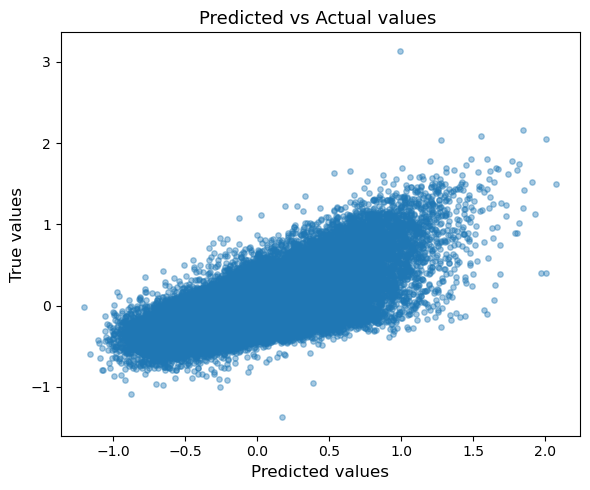

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
plt.scatter(K562_MSE['true'], K562_MSE['predicted'], alpha=0.4, s=15)
plt.xlabel("Predicted values", fontsize=12)
plt.ylabel("True values", fontsize=12)
plt.title("Predicted vs Actual values ", fontsize=13)
plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import string
import matplotlib.pyplot as plt
from collections import namedtuple
from scipy.stats import pearsonr, spearmanr
import matplotlib as mpl
sns.set_style("ticks")
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['lines.markersize'] = 20
sns.set_context('paper', font_scale=2)
%matplotlib inline

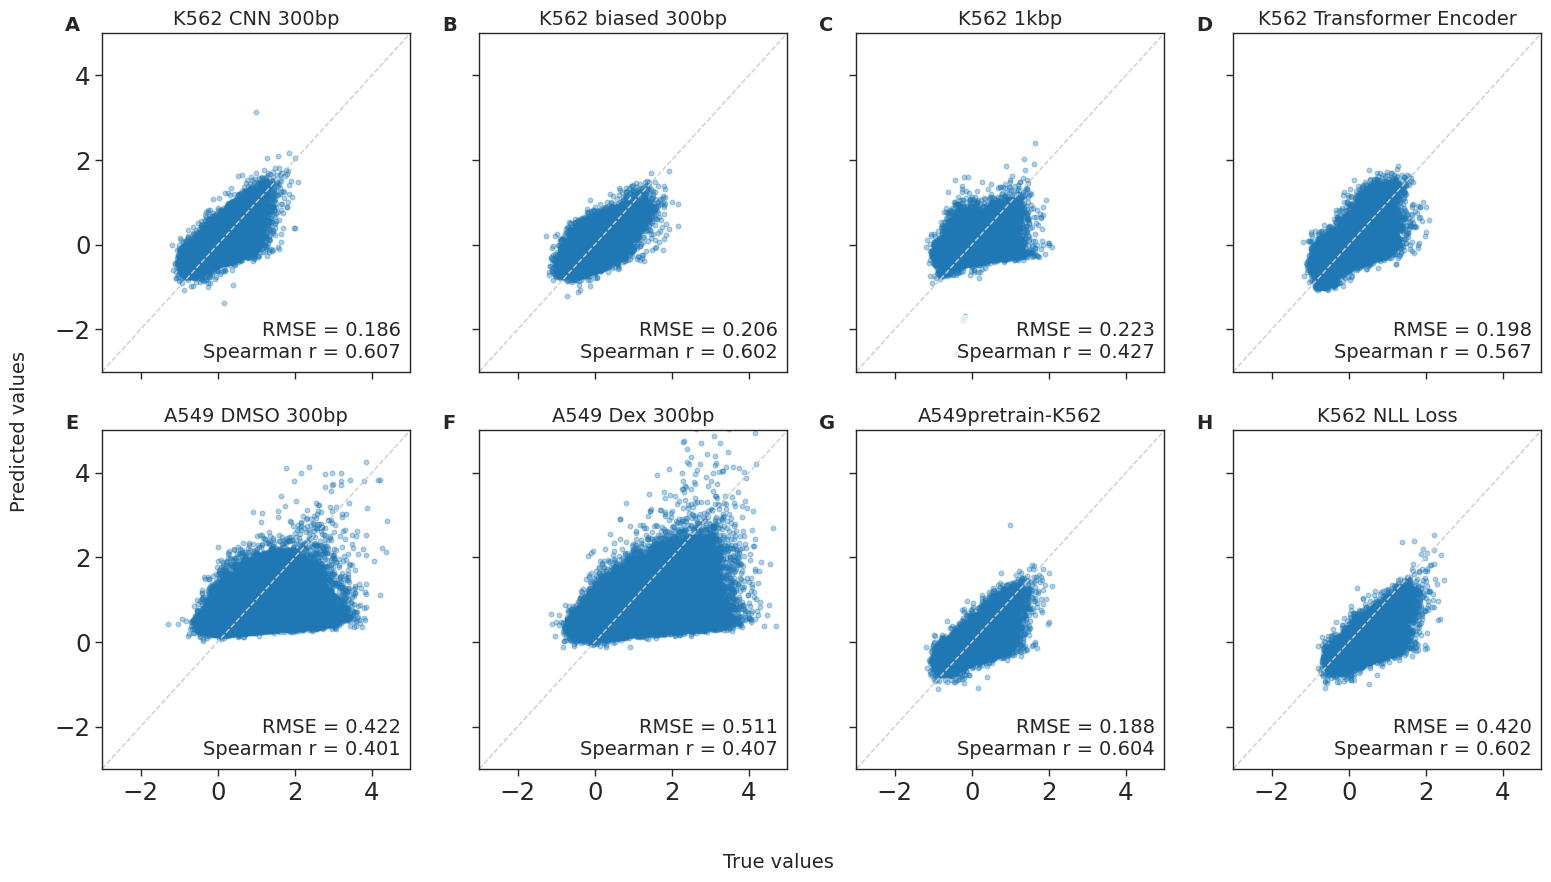

In [4]:

models = {
    "K562 CNN 300bp":K562_MSE,
    "K562 biased 300bp": K562_biased_smpl,
    "K562 1kbp":K562_1Kbp,
    "K562 Transformer Encoder":K562_TE,
    # "K562 DeepSTARR":   K562_DeepSTARR,
    "A549 DMSO 300bp":A549_DMSO,
    "A549 Dex 300bp":A549_Dex, 
    "A549pretrain-K562":A549pretrained_K562,
    "K562 NLL Loss":    K562_CustomLoss
}

def rmse(df):
    return np.sqrt(np.mean((df['true'] - df['predicted'])**2))


n_models = len(models)
n_cols = 4
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16,9), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

# plot aesthetics
point_style = dict(s=12, alpha=0.35, color="#1f77b4")  # softer blue
identity_line_color = "#cccccc"

panel_labels = list(string.ascii_uppercase)


for i, (ax, (name, df)) in enumerate(zip(axes, models.items())):
    r_val, _ = spearmanr(df["true"], df["predicted"])
    r = rmse(df)

    ax.scatter(df['true'], df['predicted'], **point_style)

    # identity line
    ax.plot([-3, 5], [-3, 5], linestyle="--", color=identity_line_color, linewidth=1)

    ax.set_xlim(-3, 5)
    ax.set_ylim(-3, 5)

    ax.set_title(name, fontsize=14)

    # ---- Panel label (A, B, C...) ----
    ax.text(-0.12, 1.05, panel_labels[i], transform=ax.transAxes, fontsize=14, fontweight="bold", va="top", ha="left")

    # Metrics box
    ax.text(0.97, 0.03, f"RMSE = {r:.3f}\nSpearman r = {r_val:.3f}", transform=ax.transAxes, ha="right", va="bottom", fontsize=14, 
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))


# remove empty axes
for j in range(len(models), len(axes)):
    axes[j].axis("off")

fig.supxlabel("True values", fontsize=14)
fig.supylabel("Predicted values", fontsize=14)
# fig.suptitle("Predicted vs True values (All Models)", fontsize=15)
plt.tight_layout()
plt.savefig('/hpc/group/igvf/revathy/plots/RMSE/BlueSTARR_RMSE_Scatterplots.pdf', transparent=True, bbox_inches="tight")
plt.show()


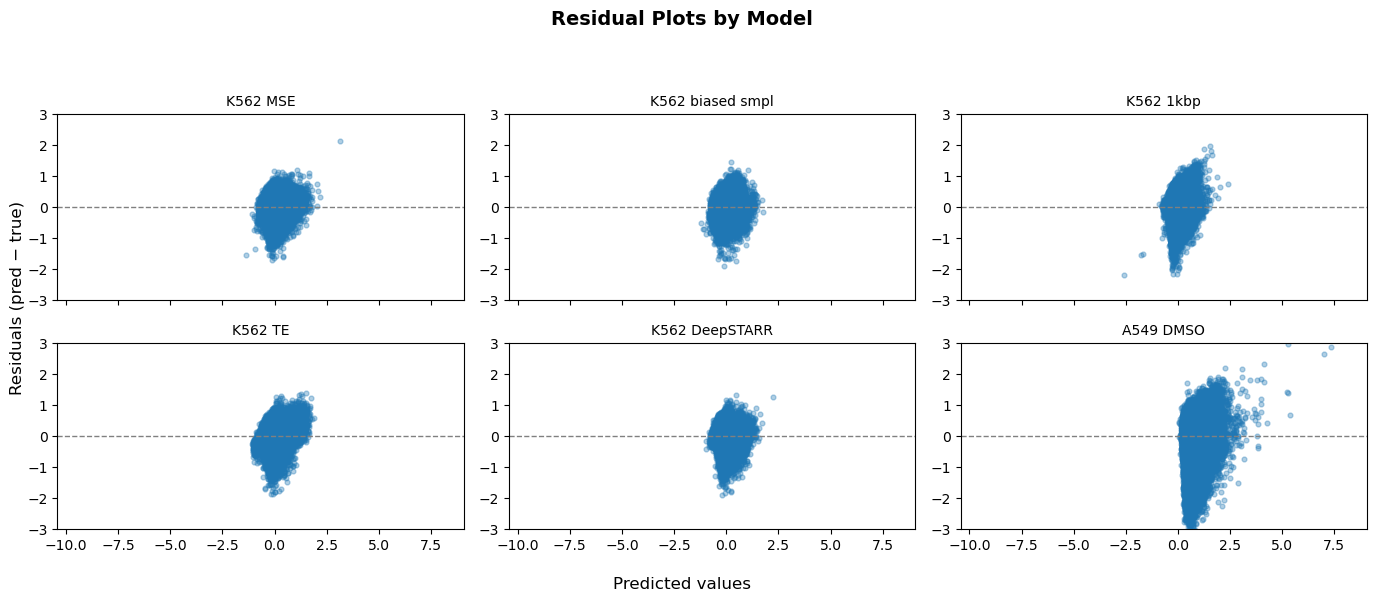

In [33]:
import matplotlib.pyplot as plt
import numpy as np

models = {
    "K562 MSE":         K562_MSE,
    "K562 biased smpl": K562_biased_smpl,
    "K562 1kbp":        K562_1Kbp,
    "K562 TE":          K562_TE,
    "K562 DeepSTARR":   K562_DeepSTARR,
    "A549 DMSO":        A549_DMSO,
}

n_models = len(models)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6), sharex=True)
axes = np.array(axes).reshape(-1)

for ax, (name, df) in zip(axes, models.items()):
    residuals = df["predicted"] - df["true"]

    ax.scatter(df["predicted"], residuals, alpha=0.35, s=12, color="#1f77b4")

    # horizontal line at residual = 0
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)

    ax.set_title(name, fontsize=10)
    ax.set_ylim(-3, 3)   # adjust if needed

# remove unused axes
for j in range(len(models), len(axes)):
    axes[j].axis("off")

fig.supxlabel("Predicted values", fontsize=12)
fig.supylabel("Residuals (pred − true)", fontsize=12)
fig.suptitle("Residual Plots by Model", fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import namedtuple
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib as mpl
sns.set_style("ticks")
sns.set_style('ticks')
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['lines.markersize'] = 20
sns.set_context('paper', font_scale=1.25)
%matplotlib inline

%matplotlib inline


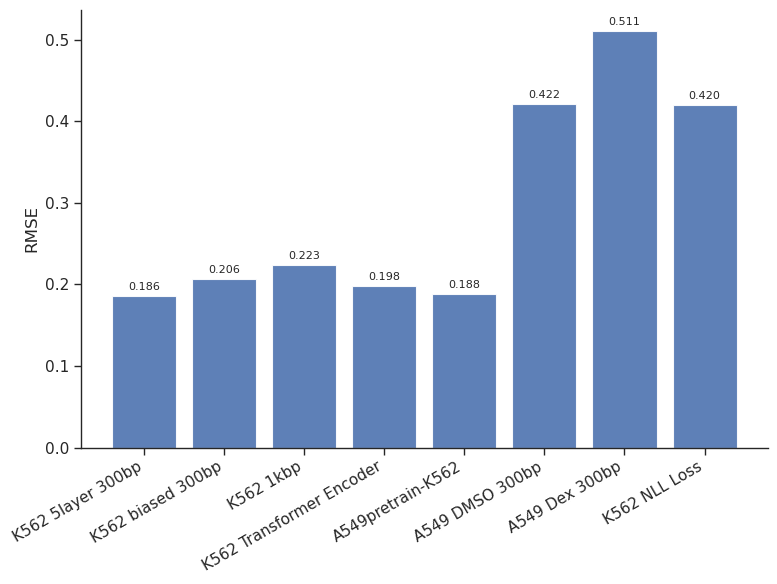

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Dictionary of RMSE values (replace with your own variables)


rmse_values = {
    "K562 5layer 300bp": K562_RMSE,
    "K562 biased 300bp": K562_biased_smpl_RMSE,
    "K562 1kbp": K562_1Kbp_RMSE,
    "K562 Transformer Encoder": K562_TE_RMSE,
    "A549pretrain-K562":A549pretrained_K562_RMSE,
    "A549 DMSO 300bp": A549_DMSO_RMSE,
    "A549 Dex 300bp": A549_Dex_RMSE,
    "K562 NLL Loss":K562_CustomLoss_RMSE
}

# Prepare data

labels = list(rmse_values.keys())
values = list(rmse_values.values())

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color="#4C72B0", alpha=0.9)

# Display RMSE numbers on top of bars
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.3f}",
             ha="center", va="bottom", fontsize=8)

plt.ylabel("RMSE", fontsize=12)
# plt.title("RMSE Across Models", fontsize=14)
plt.xticks(rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.show()


In [36]:
for name, v in rmse_values.items():
    print(name, type(v), np.shape(v))


K562 MSE <class 'numpy.float64'> ()
K562 biased smpl <class 'numpy.float64'> ()
K562 1kbp <class 'numpy.float64'> ()
K562 TE <class 'numpy.float64'> ()
K562 DeepSTARR <class 'pandas.core.frame.DataFrame'> (500479, 3)
A549 DMSO <class 'numpy.float64'> ()


# Between-Replicate correlations for the raw data

In [9]:
!zcat /hpc/group/igvf/A549/full-set/Dex-200/300-bases/data-normalized/train-counts.txt.gz | head

DNA=5   RNA=4
0.8062421825356758	0.9204464313573014	0.9057038748782145	0.9143633507525026	0.9820976344076788	1.7272382141369778	1.4524895977075734	1.028233928068291	1.2116851404017972
0.8500892932211913	0.9706643640301711	0.9520404148344901	0.972229379561683	1.030224650591418	1.8615593909120363	1.621424697879838	1.188779929601794	1.3350595029587276
0.8748131926432425	0.9977692508626846	0.9782060945621026	1.0096730511212435	1.0548327032140965	1.9142595339244535	1.7287439398794069	1.3119366051879722	1.4128964355657656
0.8745585143623974	1.0024176446496047	0.9809236828318003	1.0174411136935269	1.0586164958599402	1.9469964672869915	1.787329572040044	1.363780940006914	1.4453542922897948
0.8686919778229281	0.9970219744090094	0.9748221517515802	1.0104257079611487	1.0569280423483047	1.9298209725518198	1.8231847213277268	1.3788141492333958	1.4532341797373964
0.8599792997940133	0.9877729361293336	0.9659058062942826	1.0007377667116741	1.0509660715792262	1.8134085520179346	1.8436387469091222	1.387

In [10]:
!zcat /hpc/group/igvf/A549/full-set/DMSO-200/300-bases/data-normalized/train-counts.txt.gz | head

DNA=5   RNA=4
0.4797624986521878	0.5028645290999586	0.5098750494175405	0.5158858902116895	0.46727768201441755	1.7486005005952159	1.3147116569994095	0.9849819070351055	2.2151275344170727
0.4793313327907569	0.5118891456970608	0.5200102782697985	0.5161535462536879	0.4753983393799014	1.8766276517572082	1.3147116569994095	0.9294111538837188	2.39993200077161
0.4708710990226799	0.5166163258193525	0.5265078278849569	0.5131087072195261	0.4768772589781159	1.949459871985165	1.2799124400544992	0.8859011926808279	2.518206443425865
0.442916806669908	0.5030555262766169	0.5192822681486841	0.49250120443709566	0.4636230207338218	1.862333989271109	1.190175725791865	0.8309766110777129	2.4225695343567106
0.8062421825356758	0.9204464313573014	0.9057038748782145	0.9143633507525026	0.9820976344076788	0.7867170707384165	1.4772795192942885	2.456744226529911	2.1104813513051717
0.8500892932211913	0.9706643640301711	0.9520404148344901	0.972229379561683	1.030224650591418	0.8683690760044691	1.613001312586343	2.64930

In [11]:
!zcat /hpc/group/igvf/K562/full-set/300bp/data-normalized/train-counts.txt.gz | head


DNA=3	RNA=3
0.3241904862249436	0.30609074672368114	0.22298271550967277	0.4558322580637393	0.4781538406649796	0.5157784148376579
0.4862857293374155	0.3673088960684174	0.4236671594683783	0.2494176506386498	0.28505325116566094	0.33776639555740423
0.3971333456255559	0.39791797074078555	0.43109991665203407	0.3784267802793307	0.3907988120819545	0.34233080630818
0.2998761997580729	0.3443520900641413	0.2898775301625746	0.3010213024949222	0.4045917113319058	0.3012511095511983
0.3809238213143088	0.4132225080769696	0.3567723448154764	0.3612255629939066	0.45976330833171114	0.3560240385605072
0.5592285887380277	0.6121814934473623	0.5723223031414935	0.3698261716366187	0.372408279748686	0.3879749138159373
0.3890285834699323	0.3443520900641413	0.44596543101934555	0.25801825928136185	0.33102958199883203	0.273864645046544
0.3809238213143088	0.2907862093874971	0.4533981882030013	0.2064146074250895	0.2942485173322952	0.28299346654809543
0.41334286993680314	0.47444065742170577	0.4533981882030013	0.30102130

### RMSE on BlueSTARR CRN - test

In [4]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import spearmanr

crn = pd.read_csv('/hpc/home/rv103/igvf/revathy/models/K562/CRN/K562_CRN-.txt', sep='\t')

RMSE_final = np.sqrt(np.mean((crn['true'] - crn['pred_final'])**2))
RMSE_causal = np.sqrt(np.mean((crn['true'] - crn['pred_causal'])**2))
RMSE_residual = np.sqrt(np.mean((crn['true'] - crn['pred_residual'])**2))

Spearman_final = stats.spearmanr(np.exp(crn['pred_final']), np.exp(crn['true']))
Spearman_causal = stats.spearmanr(np.exp(crn['pred_causal']), np.exp(crn['true']))
Spearman_residual = stats.spearmanr(np.exp(crn['pred_residual']), np.exp(crn['true']))



In [5]:
print(RMSE_final)
print(RMSE_causal)
print(RMSE_residual)

print(Spearman_final)
print(Spearman_causal)
print(Spearman_residual)

0.244338130224977
0.24785940690981217
0.24607960062921633
SignificanceResult(statistic=0.3933338027406163, pvalue=2.6143065322790117e-38)
SignificanceResult(statistic=0.40416455254101163, pvalue=1.5208311477998532e-40)
SignificanceResult(statistic=0.1871117610596568, pvalue=2.5326248792575278e-09)
